# Quality Control Tutorial

Learn to use the `PlantCV` quality control submodule to evaluate your images.

# Section 1: Importing Image and Libraries

In [1]:
# Set the notebook display method
# If widget is not working, then change to inline
%matplotlib widget

# Import libraries
from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs

# Print out the version of PlantCV being used by the Jupyter kernel
pcv.__version__

'5.0.0rc2.dev48+gdd39a69a6'

## Input/Output variables

The options class mimics the workflow command-line argument parser that is used for workflow parallelization. Using it while developing a workflow in Jupyter makes it easier to convert the workflow to a script later. Remember, always keep your raw images separate from your newly processed images!

In [2]:
# Input/output options
args = WorkflowInputs(
    images=["img/image1.png"],
    names="image1",
    result="test.json",
    outdir=".",
    debug="plot"
    )

In [3]:
# Set debug to the global parameter 
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 100
# Increase text size and thickness to make labels clearer
# (size may need to be altered based on original image size)
pcv.params.text_size = 1
pcv.params.text_thickness = 1

## Read the input image

### Reading images into your environment using *pcv.readimage()*
Inputs:
   * filename = Image file to be read in
   * mode     = How the image will be read into the notebook; either 'native' (default), 'rgb', 'gray', 'csv', or 'envi'

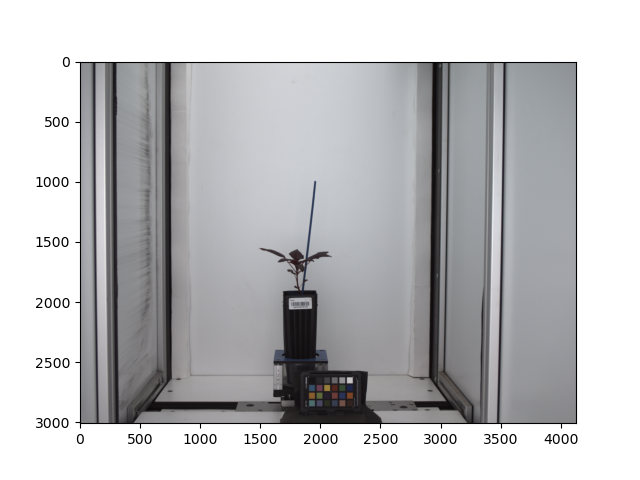

In [4]:
img, path, filename = pcv.readimage(filename=args.image1)

### Check image exposure using *pcv.qc.exposure*
Plots each channel of an RGB image as a histogram and checks saturation.
Inputs:
   * rgb_img  = An RGB image as a numpy array
   * warning_threshold = The threshold value for triggering a warning for over- or underexposure, by default 0.05

If over 5% of pixels are 0 or 255 (totally unsaturated or saturated) then a warning will be returned along with the histogram of each channel

In [5]:
# exposure check
# here we leave the `warning_threshold` at the default of 0.05
hist = pcv.qc.exposure(img)

alt.Chart(...)

### Color Quality tools
Most `pcv.qc` functions are geared towards assessing the quality of the color in an image. Most of the time that will require a color card so that we have set expectations of what some colors in the image should be.

To get started using those tools we will detect our color card.

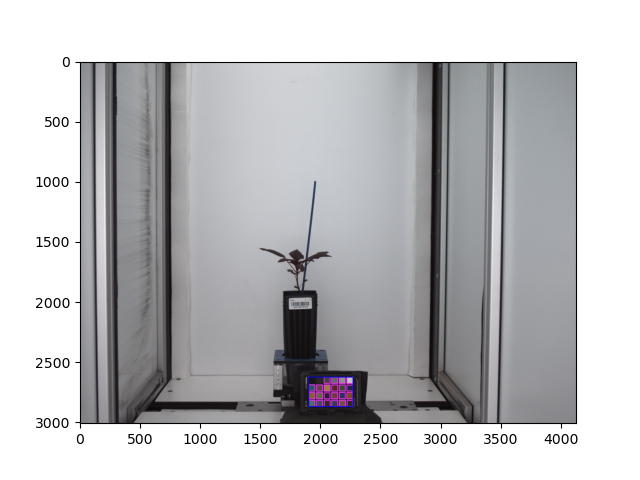

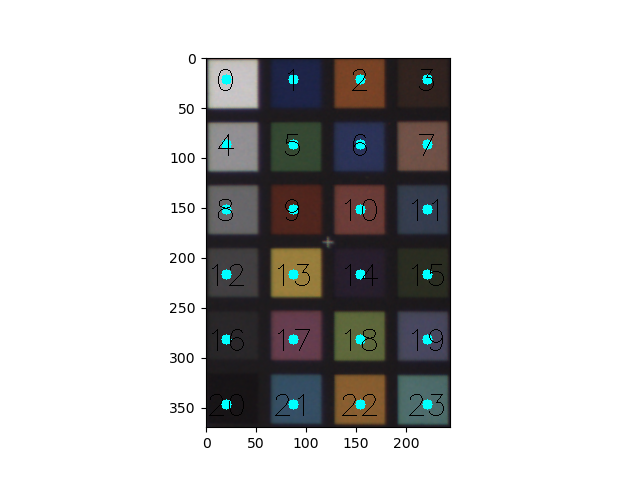

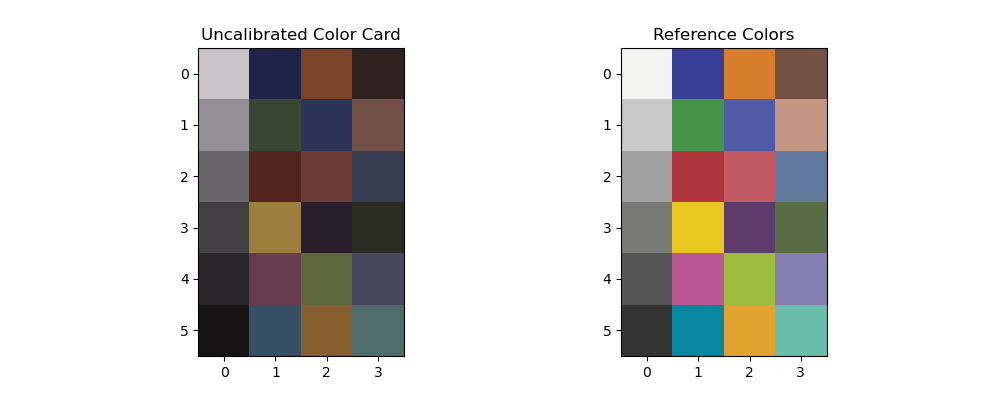

In [6]:
# color card detection
cc_mat = pcv.transform.detect_color_card(img, color_chip_size="passport")

`pcv.transform.detect_color_card` returns a matrix of color chip locations and values (in RGB). By default those colors are assessed for perceptual difference from their expected value using delta E (link to delta E ciede 2000).

The matrix returned from `pcv.transform.detect_color_card` can be used in several functions. First, it can be used in `pcv.qc.quick_color_check` to look at the values from each channel.

Ideally these are 3 straight lines with an intercept at 0 and a slope of 1. In practice these will not be perfect, but seeing whether or not the lines are straight can tell you a lot about the camera. If some channels are non-linearly related (a curved shape) then you might choose to use non-linear color correction instead of the standard affine method or look into a fix for the camera.

In [7]:
std_mat = pcv.transform.std_color_matrix(pos=3)
qcc_plot = pcv.qc.quick_color_check(target_matrix=std_mat, source_matrix=cc_mat)

alt.Chart(...)

For another way of assessing a color card we can use the `pcv.qc.color_chip_comparison` function, which takes a standard color matrix and any number of additional color matrices to compare to.
The resulting plot shows the expected (left) and observed (right) colors for each chip arranged on the Y axis by "greenness" (`G / (R + G + B)`). Greenness rank is a heuristic that we use internally to roughly estimate the age of a color card under the hypothesis that while perceptual color differences (delta E) may change based on lighting and camera setup then proportion of green light reflected by each chip should be more strongly related to the quality of the color chips themselves. We have noticed that the red macbeth color card chips often fade much faster than the surrounding chips and the greenness rank does a good job of detecting that change.

In [8]:
ccc_plot = pcv.qc.color_chip_comparison(std_mat, cc_mat)
ccc_plot

alt.VConcatChart(...)

By default running `pcv.transform.detect_color_card` (or the auto correction wrappers) will add delta E values to `pcv.outputs.metadata` as a list. Setting the `delta_E` argument to `False` will prevent the delta E metadata from being measured.

In [9]:
pcv.outputs.metadata["deltaE_uncalibrated"]

{'datatype': "<class 'list'>",
 'value': [[11.661083870590476,
   36.02118322677145,
   33.06969786504427,
   47.05387756918186,
   18.04633059763772,
   38.530999511693224,
   33.65874952306035,
   32.34066590809938,
   24.361825228333235,
   36.67308976944037,
   28.81826322236158,
   37.658783058191446,
   34.78099000225844,
   25.660472679229898,
   43.464551788128546,
   46.61517325502614,
   42.24385421220304,
   29.642089092597477,
   33.15799665646814,
   33.408324817971476,
   31.674379437720315,
   25.679888508776067,
   29.416077255247362,
   29.5783771532425]]}

This data can be used in downstream analysis to check the quality of images or of color correction.

The `pcv.transform.deltaE` function can also be used to calculate delta E and return it as a numpy matrix. That matrix can be used in the same way or to compare different methods of color correction. The `obs` argument controls the suffix for the delta E measurements in the outputs, so if you do custom color correction or use several PlantCV options you can keep the delta E values labeled for each.
The `pcv.qc.plot_deltaE` function can take a matrix of delta E values and plot them colored by perceptual bins.
As a general guideline, a delta E value less than 1 is imperceptibly different and values greater than 3.5 are clearly distinct. More granularly, the cutoffs of 1, 2, 10, and 49 are meaningful standards for how accurately a color is portrayed. Whether a particular color chip's delta E value matters for your experimental goals depends on your hypothesis and analysis plan.
In this plot the color chip is shown on the X axis and the delta E value for that chip is shown on the Y axis. This image would clearly benefit from color correction.

In [10]:
pcv.params.debug = None
de_mat = pcv.transform.deltaE(img, "passport", obs="uncalibrated")
pcv.params.debug = "plot"
p = pcv.qc.plot_deltaE(de_mat)

alt.LayerChart(...)

Next we can perform color correction, here we pick a linear method since the `pcv.qc.quick_color_check` plot did not suggest a strong non-linear relationship between the observed and expected values.

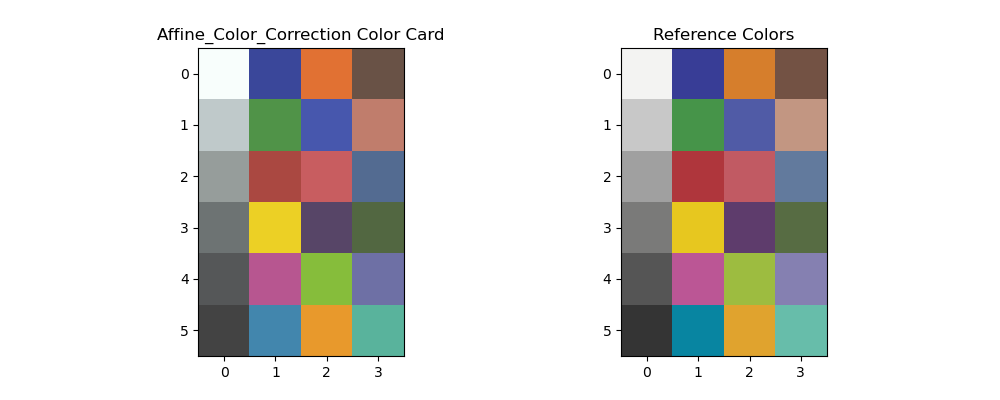

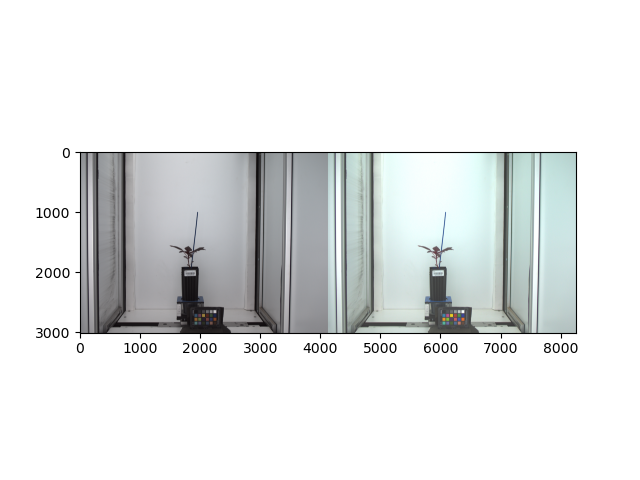

In [11]:
# Color correction
img_cc = pcv.transform.affine_color_correction(img, cc_mat, std_mat)

Calling `pcv.transform.affine_color_correction` automatically collects delta E values from the corrected image and stores them in the outputs metadata.

In [12]:
pcv.outputs.metadata["deltaE_affine_color_correction"]

{'datatype': "<class 'list'>",
 'value': [[2.0753920566290853,
   5.7099466474118445,
   3.418777406201708,
   1.8724193962874474,
   0.5532881807910802,
   0.9351665661583489,
   2.628123494799637,
   7.072463073948726,
   1.6605777144884881,
   3.615869464052399,
   1.9433052317060626,
   7.287465631077706,
   4.208727368120292,
   2.176813992744859,
   4.301626514080105,
   2.698451476232083,
   1.2460660893777593,
   1.0757323032730797,
   3.388486548866778,
   7.615875456459236,
   14.999479238988934,
   4.849618483539136,
   2.2196398712172596,
   3.631300661431425]]}

We can call `pcv.qc.plot_deltaE` again on the corrected values and we hope to see a significant improvement. Here our values are now almost all below 10, with several being almost imperceptably different from the target.

In [13]:
pcv.params.debug = None
de_mat = pcv.transform.deltaE(img_cc, "passport")
pcv.params.debug = "plot"
p = pcv.qc.plot_deltaE(de_mat)

alt.LayerChart(...)

In [14]:
# we'll clear outputs to reset for next steps
pcv.outputs.clear()

Of course the same functionality exists in the "`auto`" wrapper functions.

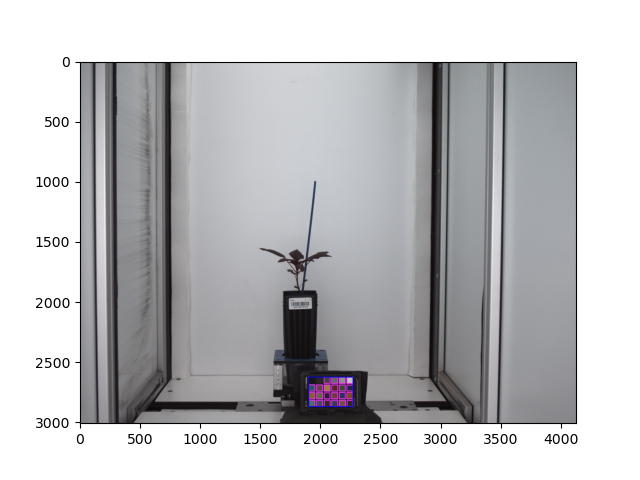

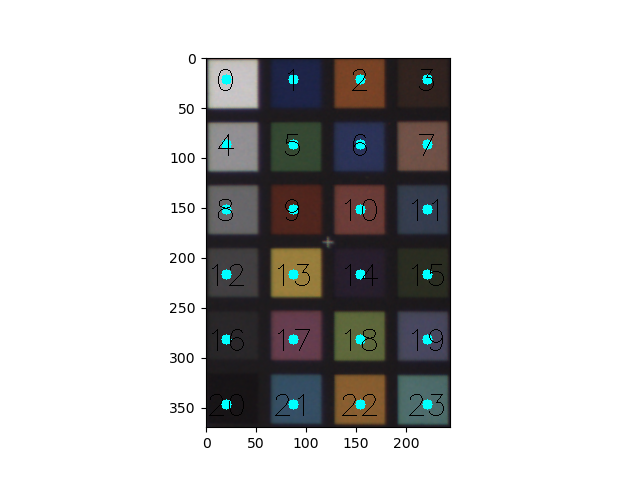

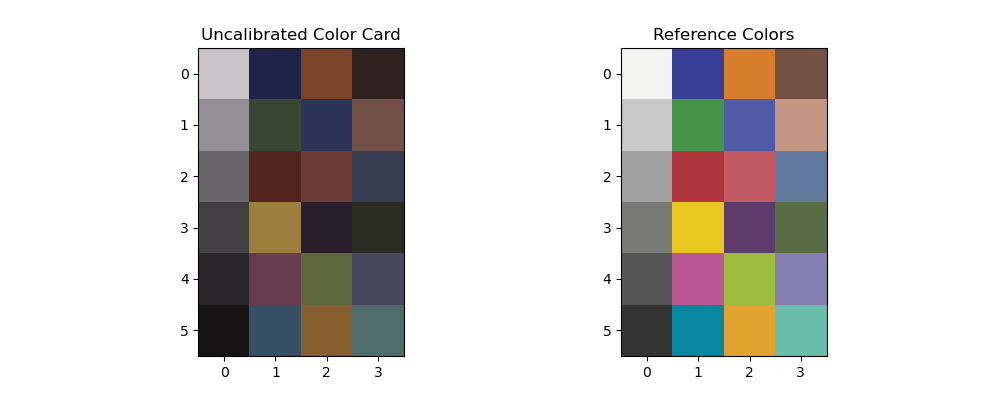

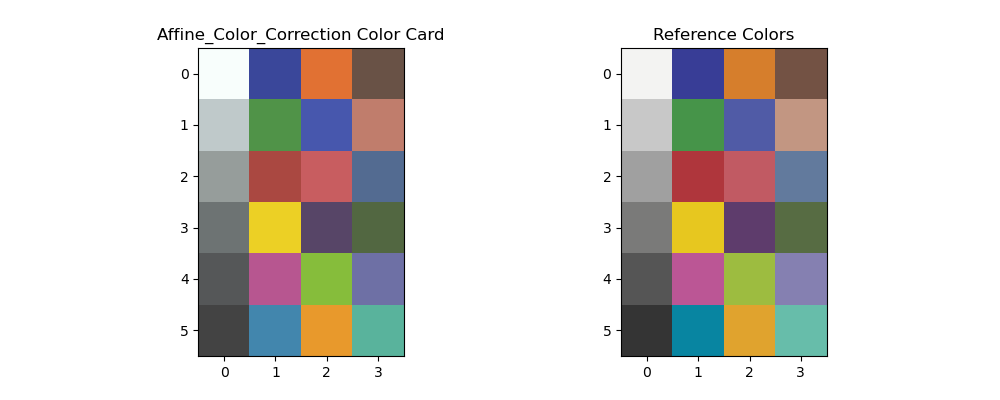

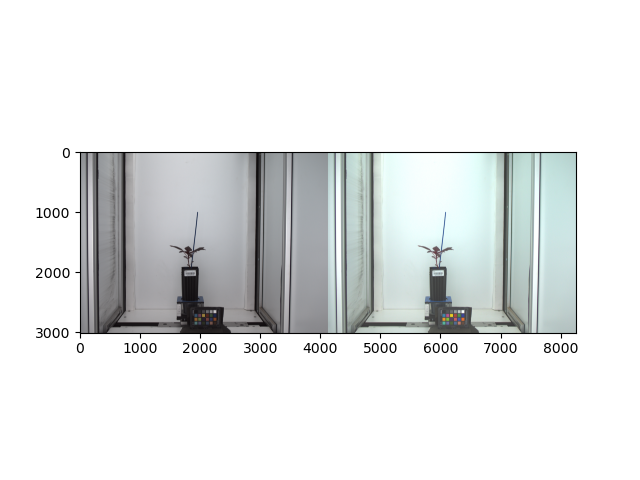

In [15]:
img_cc2 = pcv.transform.auto_correct_color(img, "passport")

In [16]:
print(pcv.outputs.metadata.keys()) # contains 2 delta E versions
pcv.outputs.clear()

dict_keys(['median_color_chip_size', 'median_color_chip_width', 'median_color_chip_height', 'deltaE_uncalibrated', 'deltaE_affine_color_correction'])


So far we have focused on quality control for a single image, which can be important in setting up an imaging workflow or as a check while you set thresholds and establish a workflow to then deploy over a large dataset, but sometimes we may want to see the results from several images at once.

The `pcv.qc.plot_deltaE` function can take a filepath as an `str` instead of a single numpy array in which case it will read images from that path, detect color cards from those images (kwargs let you control that detection), calculate delta E for each chip in each image, and return the results as a boxplot. This is useful mainly for assessing the variation in lighting/image quality over a dataset before scaling up your workflow.

In [17]:
# dataset level delta E
p = pcv.qc.plot_deltaE("img")
p

alt.LayerChart(...)

In [18]:
print(pcv.outputs.metadata.keys())

dict_keys(['median_color_chip_size', 'median_color_chip_width', 'median_color_chip_height', 'deltaE_calibrated'])


# Conclusion

The `pcv.qc` submodule can help assess color quality in your images and potentially be useful in diagnosing the lifecycle of your color card.
If you have ideas about improvements to the `qc` submodule, feature requests, or contributions to any parts of PlantCV we encourage you to open an [issue](https://github.com/danforthcenter/plantcv/issues) on Github or collaborate directly with your own [code contributions](https://docs.plantcv.org/en/stable/CONTRIBUTING/).
